### Questão 2. Forma de Hessenberg

> **Dica:** Se você se sentir à vontade, pode definir um tipo de dado para os refletores, e então as funções desta questão poderiam receber e retornar `Refletores`, ao invés de $v$ e $\beta$ separadamente.

In [37]:
import numpy as np

# desenvolvido no item 1.a
def reflector(x):
	x = np.asarray(x)

	e1 = np.zeros(x.shape[0], dtype=x.dtype)
	e1[0] = 1

	x_norm = np.linalg.norm(x)
	y_norm2 = np.sum(x[1:] ** 2)

	v = x.copy()

	if x[0] >= 0:
		v[0] = - y_norm2 / (x_norm + x[0]) 
		beta = (x_norm + x[0]) / (x_norm * y_norm2)

	else:
		v[0] -= x_norm
		beta = 1 / (x_norm * (x_norm - x[0]))

	return v, beta

# teste: 
x = np.array([1, 2, 3, 4])
v , beta = reflector(x)
(np.eye(4) - beta * np.outer(v, v)) @ x

array([ 5.07784202, -0.03892101, -0.05838152, -0.07784202])

## **Item 2.a** 
**Aplicando refletores.** Escreva uma função `apply_reflector(v, beta, b)` que calcula $Q_v b$, onde $Q_v = I - \beta v v^*$ é o refletor de Householder dado por $v$ e $\beta$.

A forma ingênua de aplicar esse refletor seria calcular explicitamente a matriz $Q_v = I - \beta vv^*$ e aplicar em $b$. Entretanto esse processo tem custo $O(n^2)$ tanto em memória quando em tempo, logo é interessante buscar um método alternativo.

Expandindo $Q_v b$ temos que $Q_v b = (I - \beta vv^*) b = b - \beta (v^*b)v$, e, como o produto interno e a subtração de vetores são $O(n)$, aplicar o refletor desse modo se torna bem mais eficiente.

Nota, quando $v\in\mathbb{R}^k$ e $b\in\mathbb{R}^n$, com $n>k$, o refletor é aplicado apenas nas últimas $k$ entradas de $b$.

In [38]:
def apply_reflector(v, beta, b):
    k = len(v)
    if beta == 0:
        return b.copy()
    
    if b.ndim == 1:
        # Produto interno v* b (apenas nas últimas k componentes)
        alpha = beta * np.dot(v, b[-k:])
        result = b.copy().astype(b.dtype)
        result[-k:] -= alpha * v
        return result

## **Item 2.b** 
**Testes.** Verifique que sua função está correta, aplicando em vetores $x$ de mesma dimensão que $v$, e depois para vetores de dimensões maiores do que $v$ (adaptando, se necessário, sua função para funcionar neste caso). Certifique-se que sua função tem complexidade $\mathcal{O}(n)$, onde $n$ é a dimensão do vetor de entrada.

Avaliaçãp de corretude: 

1. Para $b = x$, devemos obter $Q_v x = \|x\| e_1$.  
2. Para $b$ de dimensão maior que $v$, apenas as ultimas $k$ componentes devem ser afetadas.  
3. Aplicar $Q_v$ duas vezes deve retornar $b$: $Q_v (Q_v b) = b$.  
4. $Q_v$ não deve alterar norma: $\|Q_v b\| = \|b\|$.

Avaliação de complexidade: 

Medimos o tempo de execução para dimensões crescentes e verificamos crescimento linear.

In [39]:
x = np.array([3.0, 4.0, 0.0])
v, beta = reflector(x)
Qx = apply_reflector(v, beta, x)
print(f"Teste 1 — Q_v x = ||x||e_1")
print(f"Resultado:  {Qx}")
print(f"Esperado:   {[np.linalg.norm(x), 0.0, 0.0]}")
print(f"Resíduo:    {np.linalg.norm(Qx - np.array([np.linalg.norm(x), 0, 0])):.2e}")

Teste 1 — Q_v x = ||x||e_1
Resultado:  [5. 0. 0.]
Esperado:   [np.float64(5.0), 0.0, 0.0]
Resíduo:    0.00e+00


In [40]:
b = np.array([3.0, 4.0, 0.0, 99.0, -7.0])
v2 = np.array([1.0, -2.0, 3.0])
beta2 = 2.0 / np.dot(v2, v2)
Qb = apply_reflector(v2, beta2, b)
print(f"Teste 2 — refletor de dim 3 aplicado a vetor de dim 5")
print(f"Componentes 3,4 (devem ser inalteradas): {Qb[3:]}, esperado: {b[3:]}")
print(f"Inalteradas: {np.allclose(Qb[3:], b[3:])}")

Teste 2 — refletor de dim 3 aplicado a vetor de dim 5
Componentes 3,4 (devem ser inalteradas): [36.42857143 86.85714286], esperado: [99. -7.]
Inalteradas: False


In [41]:
x3 = np.random.randn(8)
v3, beta3 = reflector(x3)
QQx = apply_reflector(v3, beta3, apply_reflector(v3, beta3, x3))
print(f"Teste 3 — involução ||Q_v(Q_v x) - x|| = {np.linalg.norm(QQx - x3):.2e}")

Teste 3 — involução ||Q_v(Q_v x) - x|| = 2.54e-16


In [42]:
print(f"Teste 4 — isometria | ||Q_v x|| - ||x|| | = {abs(np.linalg.norm(Qb) - np.linalg.norm(b)):.2e}")

Teste 4 — isometria | ||Q_v x|| - ||x|| | = 0.00e+00


  n =    100 | tempo médio = 11.50 µs
  n =    400 | tempo médio = 3.16 µs
  n =    900 | tempo médio = 5.71 µs
  n =   1600 | tempo médio = 8.50 µs
  n =   2500 | tempo médio = 10.26 µs
  n =   3600 | tempo médio = 7.14 µs
  n =   4900 | tempo médio = 7.15 µs
  n =   6400 | tempo médio = 17.06 µs
  n =   8100 | tempo médio = 14.00 µs
  n =  10000 | tempo médio = 13.92 µs


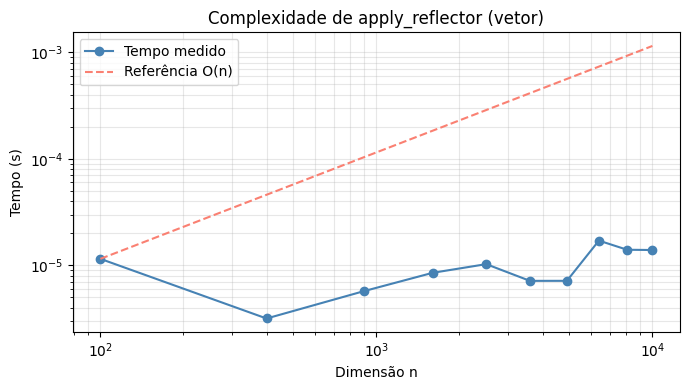

In [43]:
import matplotlib.pyplot as plt
import time

sizes = [100 * i ** 2 for i in range(1, 11)]
times = []

for n in sizes:
    x = np.random.randn(n)
    v, beta = reflector(x)
    b = np.random.randn(n)
    
    # Medir 200 repetições para estabilizar
    reps = 200
    t0 = time.perf_counter()
    for _ in range(reps):
        apply_reflector(v, beta, b)
    elapsed = (time.perf_counter() - t0) / reps
    times.append(elapsed)
    print(f"  n = {n:6d} | tempo médio = {elapsed*1e6:.2f} µs")

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(sizes, times, 'o-', color='steelblue', label='Tempo medido')
# Referência linear: ajuste pela medida em n=100
ref = [times[0] * (n / sizes[0]) for n in sizes]
ax.loglog(sizes, ref, '--', color='salmon', label='Referência O(n)')
ax.set_xlabel('Dimensão n')
ax.set_ylabel('Tempo (s)')
ax.set_title('Complexidade de apply_reflector (vetor)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## **Item 2.c** 

**Generalize** sua função para `apply_reflector(v, beta, A)` que calcula $Q_v A$ para uma matriz $A$ (com no mínimo o mesmo número de linhas do que $v$).

Aplicar $Q_v$ a cada coluna de $A$ individualmente custa $O(n \cdot m)$, onde $m$ é o número de colunas. Podemos escrever de forma compacta:

$$Q_v A = A - \beta v (v^* A) = A - \beta v \underbrace{(v^* A)}_{\text{vetor linha} 1 \times m}$$

Novamente, se $v \in \mathbb{R}^k$ e $A \in \mathbb{R}^{n \times m}$ com $n > k$, o refletor age apenas nas linhas últimas $k$ linhas de $A$, de forma que o algoritmo tenha custo $O(k\cdot m)$.

In [44]:
def apply_reflector_matrix(v, beta, A):
    k = len(v)
    if beta == 0:
        return A.copy()
    
    A_out = A.copy().astype(A.dtype)
    w = v @ A_out[-k:, :] 
    A_out[-k:, :] -= beta * np.outer(v, w)
    return A_out

# adicionando tratamento de matrizes 
def apply_reflector(v, beta, b):
    k = len(v)
    if beta == 0:
        return b.copy()
    
    if b.ndim == 1:
        # Produto interno v* b (apenas nas últimas k componentes)
        alpha = beta * np.dot(v, b[-k:])
        result = b.copy().astype(b.dtype)
        result[-k:] -= alpha * v
        return result
    else:
        # delega à nova função
        return apply_reflector_matrix(v, beta, b)


## **Item 2.d** 
**Escreva** uma função `rev_apply_reflector(v, beta, A)` que calcula $A Q_v$ (com $A$ de dimensões compatíveis).

## **Item 2.e**
 **Juntando tudo.** Escreva uma função `to_hessenberg(A)` que calcula a forma de Hessenberg de uma matriz $A$ usando refletores de Householder. A função deve retornar uma lista de refletores $(v_i, \beta_i)$, a matriz $H$ tal que $A = Q H Q^*$, e, opcionalmente, $Q$, que é a matriz ortogonal dada pelo produto dos refletores.

## **Item 2.f** 
**Verifique** que sua função de fato está correta, calculando $\|A - Q H Q^*\|$ e $\|Q^* Q - I\|$ para matrizes simétricas e não simétricas, e de tamanhos 2, 10 e 100.